In [35]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import cartopy
import cartopy.crs as ccrs
import os
import pickle
from regrid import regrid
import pandas as pd
from scipy.stats import linregress
from ll_xy import lonlat_to_xy
from scipy.spatial import KDTree

Pond Data

https://data.seaice.uni-bremen.de/MeltPonds-Albedo/MPD2/7-day/netcdf/2022/

NSIDC Grid Data

https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0771_polarstereo_anc_grid_info/

https://nsidc.org/data/nsidc-0771/versions/1

SIC Data

https://nsidc.org/data/nsidc-0051/versions/2#anchor-data-access-tools

https://cmr.earthdata.nasa.gov/virtual-directory/collections/C3177837840-NSIDC_CPRD/temporal/2022/08/14

/tmp/ipykernel_12190/2338989656.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conc_lon = np.array(conc_lonlat['longitude'])
/tmp/ipykernel_12190/2338989656.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conc_lat = np.array(conc_lonlat['latitude'])
/tmp/ipykernel_12190/2338989656.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn mor

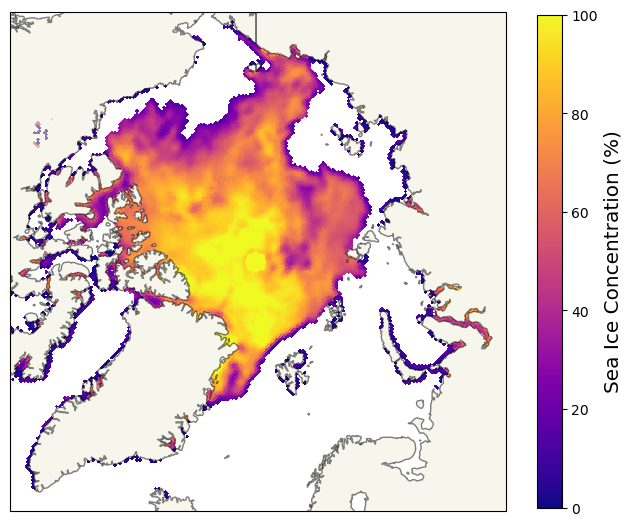

In [52]:
conc_d = Dataset('../aux_data/NSIDC0051_SEAICE_PS_N25km_20220814_v2.0.nc')
conc_lonlat = Dataset('../aux_data/NSIDC0771_LatLon_PS_N25km_v1.1.nc')
conc25 = np.array(conc_d['F17_ICECON'][0])
conc_lon = np.array(conc_lonlat['longitude'])
conc_lat = np.array(conc_lonlat['latitude'])

grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
lon = np.fliplr(np.rot90(np.rot90(lon)))
lat = np.fliplr(np.rot90(np.rot90(lat)))


conc12 = regrid(conc25,conc_lon,conc_lat,lon,lat)

conc12[conc12>1]=np.nan
conc12[conc12==0]=np.nan
conc12[lat>89]=1

fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(lon,
                  lat,
                  100*conc12,
                  vmin = 0,
                  vmax = 100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Sea Ice Concentration (%)',fontsize='x-large')
pickle.dump(conc12,open('conc.p','wb'))

In [53]:
d0 = Dataset('../ponds/20220729_7daycomp_mpd2.nc')

In [54]:
files = os.listdir('../ponds')
mp_files = sorted([f for f in files if 'mpd2' in f])

mp_data_list = [Dataset('../ponds/'+x)['mpf_std_temporal'] for x in mp_files]
mp_data_full = 100*np.nanmean(mp_data_list,axis=0)
mp_data_mask = mp_data_full.copy()
mp_data_mask[np.isnan(conc12)]=np.nan

ab_data_list = [Dataset('../ponds/'+x)['alb_ntbc'] for x in mp_files]
ab_data_full = np.nanmean(ab_data_list,axis=0)
ab_data_mask = ab_data_full.copy()
ab_data_mask[np.isnan(conc12)]=np.nan

/tmp/ipykernel_12190/3519183812.py:5: RuntimeWarning: Mean of empty slice
  mp_data_full = 100*np.nanmean(mp_data_list,axis=0)
/tmp/ipykernel_12190/3519183812.py:10: RuntimeWarning: Mean of empty slice
  ab_data_full = np.nanmean(ab_data_list,axis=0)


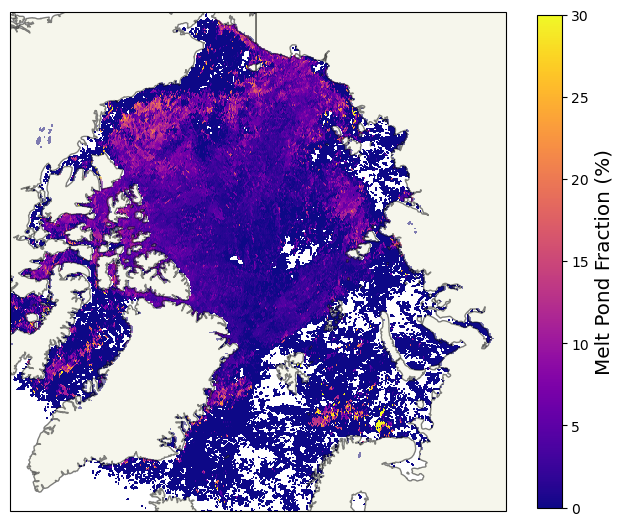

In [55]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(lon,
                  lat,
                  mp_data_full,
                  vmin = 0,
                  vmax = 30,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Melt Pond Fraction (%)',fontsize='x-large')

plt.savefig('../figs/MPF_no_mask.png',dpi=500,bbox_inches='tight')

In [56]:
mp_data_missing=mp_data_mask.copy()

mp_data_missing[conc12>0.1]=1
mp_data_missing[~np.isnan(mp_data_mask)]=np.nan

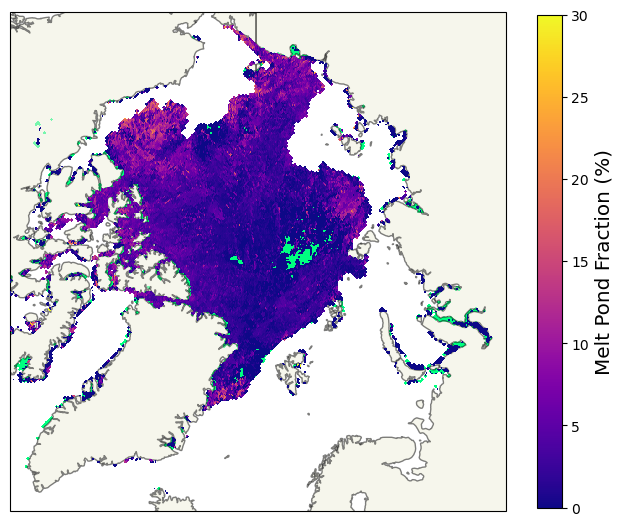

In [57]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(lon,
                  lat,
                  mp_data_mask,
                  vmin = 0,
                  vmax = 30,
                 transform=ccrs.PlateCarree(),
                  zorder=5,
                  cmap='plasma',
                 )

ax.pcolormesh(lon,
                  lat,
                  mp_data_missing,
                  vmin = 0,
                  vmax = 1,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='winter',
                 )

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Melt Pond Fraction (%)',fontsize='x-large')

plt.savefig('../figs/MPF_masked_highlighted.png',dpi=500,bbox_inches='tight')

In [59]:
inds_to_fill=np.argwhere(mp_data_missing==1)
psnx,psny=lonlat_to_xy(lon,lat,hemisphere='n')
xys_to_fill = [(psnx[i,j],psny[i,j]) for i,j in inds_to_fill]
inds_full = np.argwhere(~np.isnan(mp_data_full))
vfull = np.array([float(mp_data_full[i,j]) for (i,j) in inds_full])
xfull = np.array([float(psnx[i,j]) for (i,j) in inds_full])
yfull = np.array([float(psny[i,j]) for (i,j) in inds_full])
track_tree = KDTree(list(zip(xfull,yfull)))
tree_output=track_tree.query(xys_to_fill,k=10)
mean_fractions=[np.nanmean(vfull[ind]) for ind in tree_output[1]]
mpf_data_filled=mp_data_mask.copy()
for (i,j),mean_frac in zip(inds_to_fill,mean_fractions):
    mpf_data_filled[i,j] = mean_frac



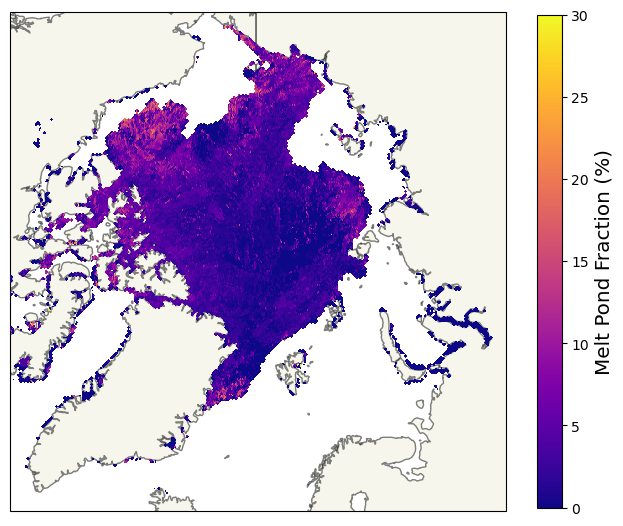

In [61]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(lon,
                  lat,
                  mpf_data_filled,
                  vmin = 0,
                  vmax = 30,
                 transform=ccrs.PlateCarree(),
                  zorder=5,
                  cmap='plasma',
                 )


cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Melt Pond Fraction (%)',fontsize='x-large')

plt.savefig('../figs/MPF_interpolated.png',dpi=500,bbox_inches='tight')

In [63]:
# is2_df = pickle.load(open('/home/robbie/Dropbox/algae/track_coords.p','rb'))
is2_df = pd.read_hdf('../aux_data/ridged_fraction.h5')

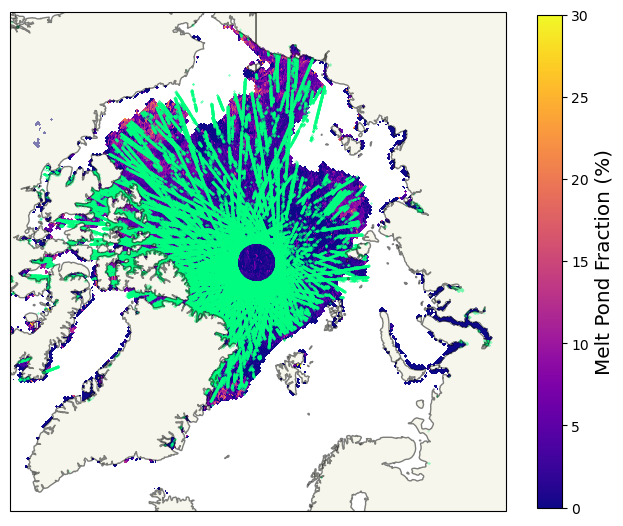

In [64]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)



data_mask = 100*mp_data_full.copy()

data_mask[np.isnan(conc12)]=np.nan

m = ax.pcolormesh(lon,
                  lat,
                  mpf_data_filled,
                  vmin = 0,
                  vmax = 30,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

ax.scatter(is2_df['lon'],
                  is2_df['lat'],
                 transform=ccrs.PlateCarree(),
                  zorder=0,
               color='springgreen',s=0.1,
                 )
    
cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Melt Pond Fraction (%)',fontsize='x-large')

plt.savefig('../figs/is2_tracks_on_mpf.png',dpi=500,bbox_inches='tight')

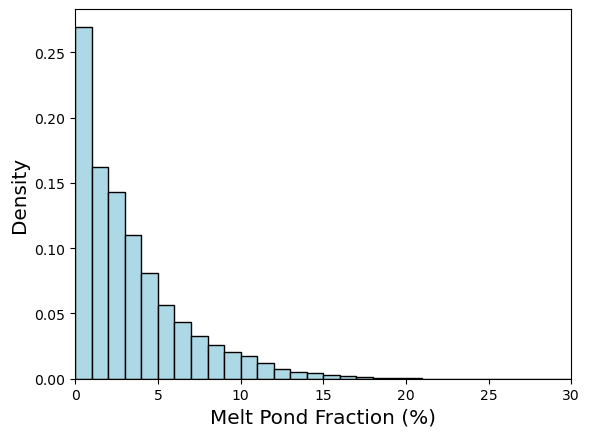

In [24]:
plt.hist(mp_data_mask.flatten(),density=True,bins=np.arange(0,31,1),edgecolor='k',color='lightblue')
plt.xlim(0,30)
plt.ylabel('Density',fontsize='x-large')
plt.xlabel('Melt Pond Fraction (%)',fontsize='x-large')
plt.savefig('../figs/mpf_histogram.png',dpi=500,bbox_inches='tight')

In [ ]:
# https://data.seaice.uni-bremen.de/MeltPonds-Albedo/MPD2/7-day/netcdf/2022/
# https://brage.npolar.no/npolar-xmlui/handle/11250/3013026 #P62
#29 July - 14 August
# https://nsidc.org/sites/default/files/documents/technical-reference/icesat2_atl07_10_20_21_atbd_v007.pdf
# https://nsidc.org/sites/default/files/documents/user-guide/atl07ql-v007-userguide.pdf